# Notebook 02 - Data Quality Assessment

**Project:** Bankruptcy Risk Analytics Platform

## Objective
Assess the quality, integrity, and reliability of the dataset before feature engineering and machine learning.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=(10,5)

DATA_PATH='../data/datasets/american_bankruptcy.csv'
df=pd.read_csv(DATA_PATH)


## 2. Dataset Snapshot

In [2]:
display(df.head())
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


Rows: 78,682
Columns: 21


## 3. Data Types Validation

In [3]:
dtype_report=pd.DataFrame({
    'Column':df.columns,
    'DataType':df.dtypes.astype(str)
})
display(dtype_report)

,Column,DataType
company_name,company_name,str
status_label,status_label,str
year,year,int64
X1,X1,float64
X2,X2,float64
X3,X3,float64
X4,X4,float64
X5,X5,float64
X6,X6,float64
X7,X7,float64


## 4. Missing Value Assessment

,Missing,Percent
company_name,0,0.0
status_label,0,0.0
year,0,0.0
X1,0,0.0
X2,0,0.0
X3,0,0.0
X4,0,0.0
X5,0,0.0
X6,0,0.0
X7,0,0.0


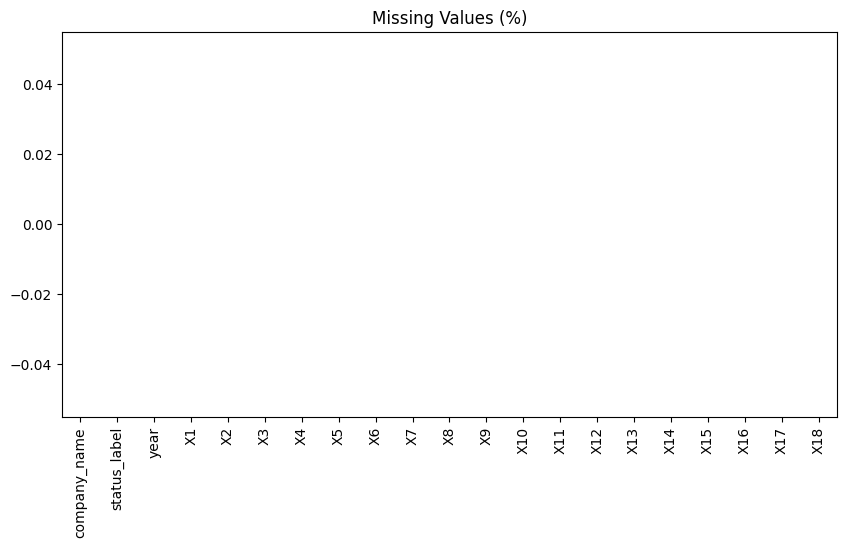

In [4]:
missing=df.isna().sum().to_frame('Missing')
missing['Percent']=100*missing['Missing']/len(df)
display(missing)
missing['Percent'].plot(kind='bar',title='Missing Values (%)')
plt.show()

## 5. Duplicate Assessment

In [5]:
print("Duplicate Rows:",df.duplicated().sum())
print("Duplicate Company-Year Records:",
      df.duplicated(subset=['company_name','year']).sum())

Duplicate Rows: 0
Duplicate Company-Year Records: 0


## 6. Target Integrity

status_label
alive     73462
failed     5220
Name: count, dtype: int64

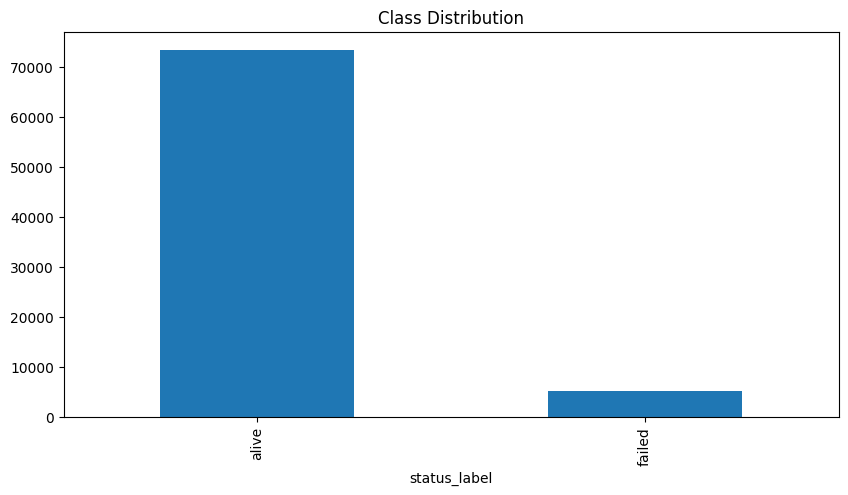

Class Ratio
status_label
alive     93.37
failed     6.63
Name: count, dtype: float64


In [6]:
target=df['status_label'].value_counts()
display(target)
target.plot(kind='bar',title='Class Distribution')
plt.show()

print('Class Ratio')
print((target/len(df)*100).round(2))

## 7. Company Integrity

count    8971.000000
mean        8.770706
std         6.421565
min         1.000000
25%         3.000000
50%         7.000000
75%        14.000000
max        20.000000
dtype: float64

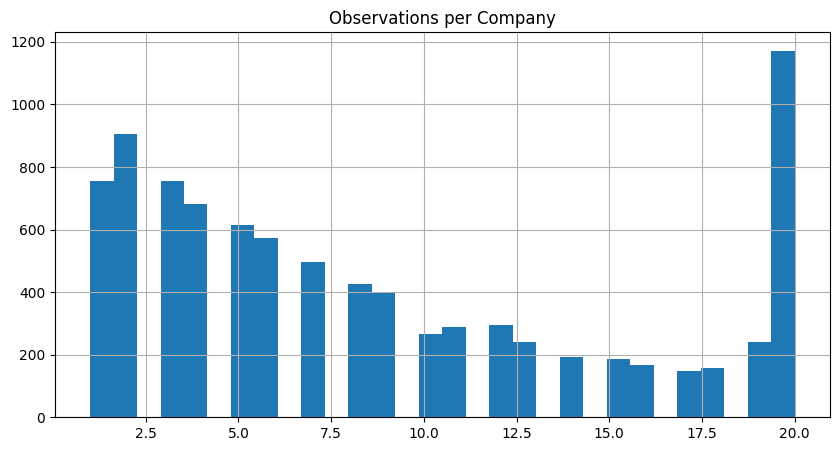

In [7]:
company=df.groupby('company_name').size()
display(company.describe())

company.hist(bins=30)
plt.title('Observations per Company')
plt.show()

## 8. Year Validation

Year Range: 1999 - 2018


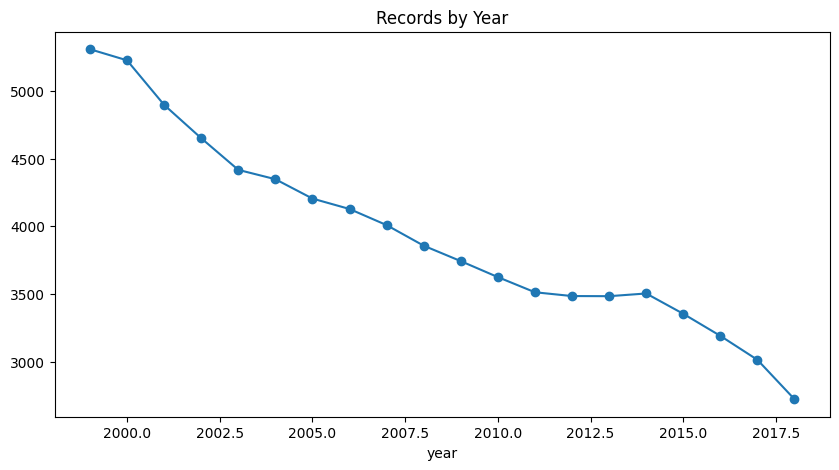

In [8]:
print("Year Range:",df['year'].min(),"-",df['year'].max())
df['year'].value_counts().sort_index().plot(marker='o',title='Records by Year')
plt.show()

## 9. Constant & Low Variance Features

In [9]:
numeric=df.select_dtypes(include='number')
constant=[c for c in numeric.columns if numeric[c].nunique()==1]
low_var=numeric.var().sort_values()

print("Constant Features:",constant)
display(low_var.head(10))

Constant Features: []


year    3.297939e+01
X3      4.255955e+05
X5      1.125225e+06
X6      1.601571e+06
X7      1.784839e+06
X12     2.233959e+06
X4      4.048237e+06
X14     8.634121e+06
X11     1.051167e+07
X13     1.424838e+07
dtype: float64

## 10. Invalid Value Checks

In [10]:
negative_counts=(numeric<0).sum().sort_values(ascending=False)
display(negative_counts.to_frame('Negative Values'))

print("Review whether negative values are valid for each financial variable based on business meaning.")

,Negative Values
X15,40277
X6,34001
X12,28498
X4,23012
X13,6603
X9,13
X16,13
X1,6
X2,6
X18,3


Review whether negative values are valid for each financial variable based on business meaning.


## 11. Outlier Overview (IQR)

,Outlier Count
X15,17867
X6,17004
X12,13251
X11,12641
X5,12435
X17,12366
X4,12218
X14,11781
X2,11594
X10,11521


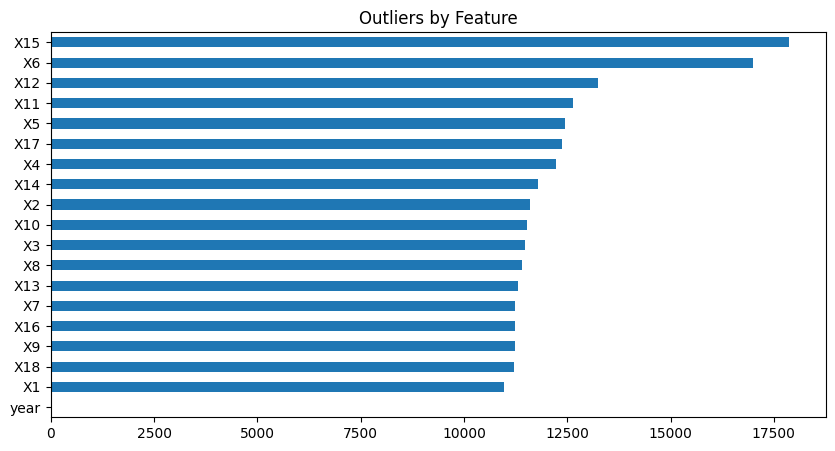

In [11]:
Q1=numeric.quantile(.25)
Q3=numeric.quantile(.75)
IQR=Q3-Q1

outliers=((numeric<(Q1-1.5*IQR))|(numeric>(Q3+1.5*IQR))).sum()
display(outliers.sort_values(ascending=False).to_frame('Outlier Count'))

outliers.sort_values().plot(kind='barh',title='Outliers by Feature')
plt.show()

## 12. Data Quality Scorecard

In [12]:
scorecard=pd.DataFrame({
'Check':['Missing Values','Duplicate Rows','Company-Year Duplicates','Target Labels','Year Range'],
'Result':[
'PASS' if df.isna().sum().sum()==0 else 'FAIL',
'PASS' if df.duplicated().sum()==0 else 'REVIEW',
'PASS' if df.duplicated(subset=['company_name','year']).sum()==0 else 'REVIEW',
'PASS' if set(df['status_label'].unique())<=set(['alive','failed','bankrupt']) else 'REVIEW',
'PASS'
]})
display(scorecard)

,Check,Result
0,Missing Values,PASS
1,Duplicate Rows,PASS
2,Company-Year Duplicates,PASS
3,Target Labels,PASS
4,Year Range,PASS


## 13. Executive Findings

In [13]:
findings=[
'Dataset completeness is acceptable if no missing values are detected.',
'Class imbalance should be addressed during model development.',
'Outliers are expected in financial datasets and should not be removed blindly.',
'Validate negative values using feature definitions before preprocessing.'
]

for i,f in enumerate(findings,1):
    print(f'{i}. {f}')

1. Dataset completeness is acceptable if no missing values are detected.
2. Class imbalance should be addressed during model development.
3. Outliers are expected in financial datasets and should not be removed blindly.
4. Validate negative values using feature definitions before preprocessing.
